In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
df = pd.read_sql_query(
    '''
    SELECT uid,
           timestamp AS commits
    FROM checker
    WHERE uid LIKE 'user_%'
    ''',
    conn,
    parse_dates=['commits'],
)

In [4]:
df['hour'] = df['commits'].dt.hour
df['weekday'] = df['commits'].dt.dayofweek
df.drop(columns='commits', axis=1, inplace=True)

print(df.shape)
df.head()

(3207, 3)


,uid,hour,weekday
0,user_4,5,4
1,user_4,5,4
2,user_4,5,4
3,user_4,5,4
4,user_4,5,4


In [5]:
weekday_pivot = df.pivot_table(index='weekday',
                               columns='uid',
                               aggfunc='count',
                               values='uid',
                               fill_value=0
)
sum = weekday_pivot.sum().sort_values(ascending=False).index
weekday_pivot = weekday_pivot[sum]
weekday_pivot = weekday_pivot.reindex(list(range(0, 7)), fill_value=0)
print(weekday_pivot.shape)
weekday_pivot

(7, 30)


uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
weekday,,,,,,,,,,,,,,,,,,,,,
0,35,50,24,14,7,0,23,5,0,46,...,8,10,0,0,1,0,2,0,0,3
1,86,87,131,44,9,1,0,0,16,11,...,4,5,0,0,0,5,3,0,0,0
2,33,0,32,15,0,34,8,0,37,0,...,1,0,0,0,4,3,0,0,0,0
3,108,17,4,40,78,51,96,7,77,7,...,17,14,15,5,2,0,2,0,6,0
4,61,0,0,10,10,2,7,35,1,59,...,0,0,0,0,0,0,0,0,0,0
5,0,79,31,66,21,16,3,90,4,3,...,32,0,0,4,2,0,0,0,0,0
6,45,26,13,44,51,69,28,7,2,8,...,0,31,27,20,9,0,1,8,0,0


In [6]:
hour_pivot = df.pivot_table(index='hour',
                            columns='uid',
                            aggfunc='count',
                            values='uid',
                            fill_value=0
)
sum = hour_pivot.sum().sort_values(ascending=False).index
hour_pivot = hour_pivot[sum]
hour_pivot = hour_pivot.reindex(list(range(0, 24)), fill_value=0)
print(hour_pivot.shape)
hour_pivot

(24, 30)


uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0,4,0,0,0,4,0,2,0,0,...,0,0,0,0,2,0,0,0,0,0
1,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,13,0,2,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,3,6,0,0,10,2,0,3,0,...,1,0,0,0,0,0,0,0,0,0
8,0,6,0,0,0,5,2,0,9,6,...,2,0,0,0,0,1,0,0,1,0


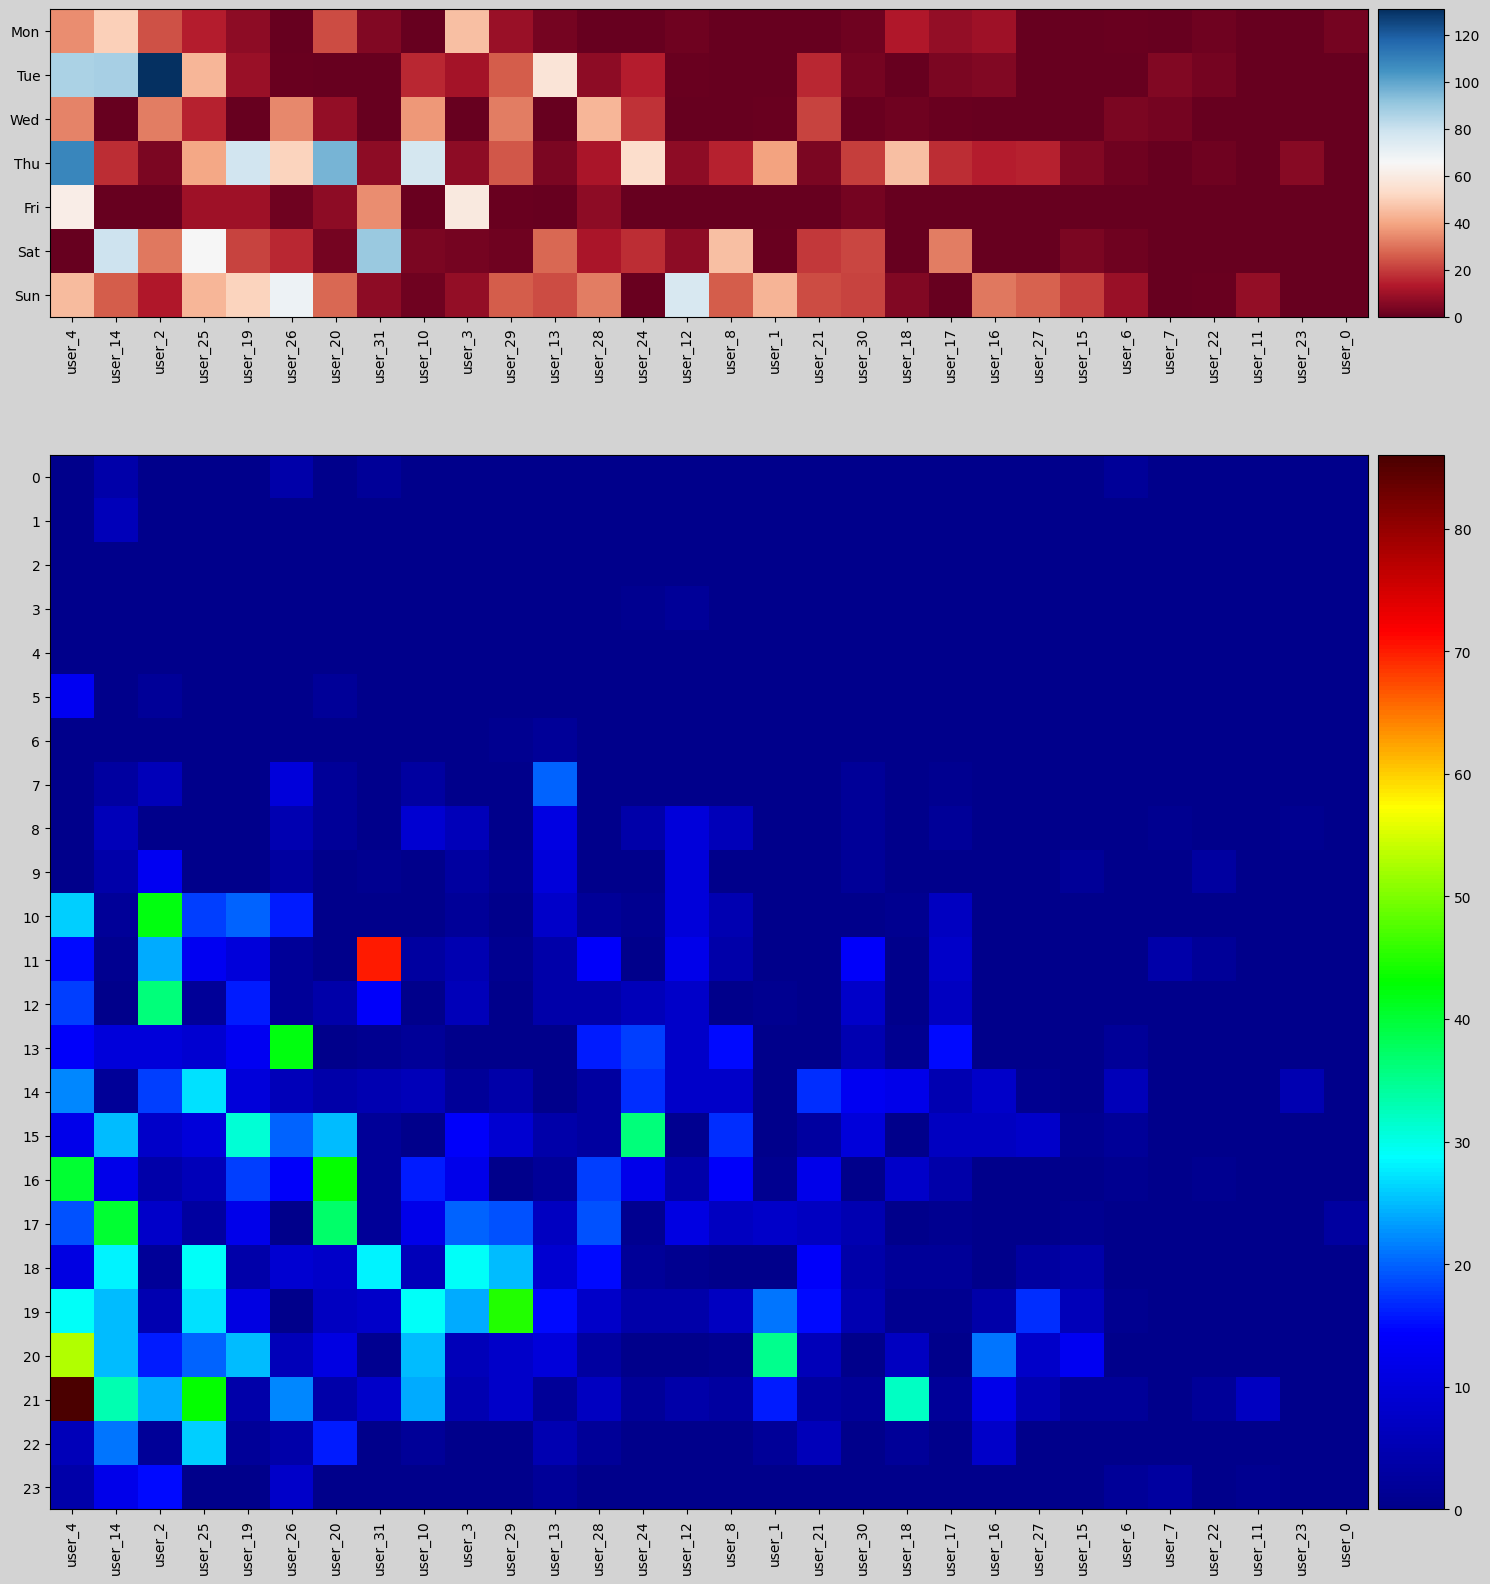

In [7]:
fig, ax = plt.subplots(2,1, figsize=(15,21))
fig.patch.set_facecolor('lightgray')

im1 = ax[0].imshow(weekday_pivot, cmap='RdBu')
divider1 = make_axes_locatable(ax[0])
cax1 = divider1.append_axes('right', size='5%', pad=0.1)
plt.colorbar(im1, cax=cax1)
ax[0].set_xticks(
    range(len(weekday_pivot.columns)),
    labels=weekday_pivot.columns, rotation=90
)
ax[0].set_yticks(
    range(len(weekday_pivot.index)),
    labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)

colors = ['#00008B','blue','cyan','#00FF00','yellow', 'red','#4B0000']
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

im2 = ax[1].imshow(hour_pivot, cmap=custom_cmap)
divider2 = make_axes_locatable(ax[1])
cax2 = divider2.append_axes('right', size='5%', pad=0.1)
plt.colorbar(im2, cax=cax2)

ax[1].set_xticks(range(len(hour_pivot.columns)), labels=hour_pivot.columns, rotation=90)
ax[1].set_yticks(range(len(hour_pivot.index)), labels=hour_pivot.index)

plt.subplots_adjust(hspace=-0.5)
plt.tight_layout()
plt.show()

- Which user has the most commits on Tue? user_2
- Which user has the most commits on Thu? user_4
- On which weekday do the users not like making a lot of commits? Fri
- Which user at which hour made the largest number of commits? user_4, 21

In [8]:
conn.close()